Rough vol Calibration
---

In [1]:
# Downloading the needed libraries
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import time
from diffrax import *
import pandas as pd
import scipy.signal as signal
import scipy.special as special
from scipy.optimize import minimize
from scipy.optimize import bisect
from scipy.stats import norm
from scipy.stats import multivariate_normal
from concurrent.futures import ProcessPoolExecutor
num_processes = 10  # Adjust based on your machine's CPU cores and task requirements

# Importing the other codes we need
from controls import *
from hybrid_joint import *
from Jackels import impliedVolJaeckelRational
%matplotlib inline
from scipy import stats
from scipy.stats import norm
import sys



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found

In [2]:
def progressBar(value, endvalue, message = "Running in progress", bar_length=20):
    percent = float(value) / endvalue
    arrow = '-' * int(round(percent * bar_length)-1) + '>'
    spaces = ' ' * (bar_length - len(arrow))
    sys.stdout.write("\r{0}: [{1}] {2}%".format(message,arrow + spaces, int(round(percent * 100))))
    sys.stdout.flush()

Quadratic rough Heston model - RDE version

$$ \begin{cases}\mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \\ \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t \end{cases} $$

with $\theta$ some function chosen to match the VIX futures? Check this is the same as solving $V$ first and then taking the exponential martingale.

$$S_t =S_0 \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$


This is equivalent to

$$
\begin{cases}
\displaystyle \frac{\mathrm{d}S_t}{S_t} & = \displaystyle- \frac{\sigma_t^2}{2}\mathrm{d}t + \sigma_t \circ \mathrm{d}W_t, \\
\displaystyle \mathrm{d}Z_t & = \displaystyle\lambda \theta(t)\mathrm{d}t + \lambda \eta \sigma_t \circ \mathrm{d} W^H_t,\\
\displaystyle \sigma_t & = \displaystyle\sqrt{a(Z_t - b)^2 + c}.
\end{cases}
$$

In [3]:
class RDE_QuadHeston:
    
    def __init__(self, nb_grid_points, nbPaths, T, H, S0):
        """
        nb_grid_points: number of points in the simulation grid
        H: Hurst parameter
        M: number of paths to simulate
        T: time horizon
        """
        self.S0 = S0
        self.epsilon = 1./nb_grid_points #time step
        # smaller time step
        self.solver_epsilon = 0.02*self.epsilon
        # lag (it has to be slightly bigger than the time step)
        self.lag = 1.2*self.epsilon
        self.nb_grid_points = nb_grid_points
        self.nbPaths, self.T, self.H = nbPaths, T, H

        self.kappa = 1 # kappa parameter for the Hybrid scheme
        
        # create the time grid (over the time horizon 1)
        self.times = jnp.arange(0., 1., self.epsilon)
        # every point x in the grid is approximated with the closest lower integer to x*eps
        # needed for the subsampling
        self.every_nth_pt = int(self.nb_grid_points*self.epsilon)
        

    def run__init__(self, timerYesNo = False):
        t0 = time.time()

        args = (self.nb_grid_points, self.T, self.kappa)
        num_processes = 8  # Adjust based on your machine's CPU cores and task requirements
        
        with ProcessPoolExecutor(max_workers=num_processes) as executor:
            self.futures = [executor.submit(degenerate_fbm_1_bm_1_bm_wrapper, args) for _ in range(self.nbPaths)]
            self.results = [future.result() for future in self.futures]

        self.list_fbm, self.list_bm1, self.list_bm2 = zip(*self.results)

        self.stacked_fbm = jnp.stack(self.list_fbm).T
        self.stacked_bm1 = jnp.stack(self.list_bm1).T
        self.stacked_bm2 = jnp.stack(self.list_bm2).T
        
        self.bm1_interp = LinearInterpolation(self.times, self.stacked_bm1)
        self.bm2_interp = LinearInterpolation(self.times, self.stacked_bm2)
        self.fbm_interp = LinearInterpolation(self.times, self.stacked_fbm)

        self.bm1_control = evaluate_and_reshape(self.bm1_interp.evaluate)
        self.bm2_control = evaluate_and_reshape(self.bm2_interp.evaluate)
        self.fbm_control = evaluate_and_reshape(self.fbm_interp.evaluate)
        
        self.fbm_fun = lambda t: self.fbm_interp.evaluate(0,t)
        self.fbm_lagged_control_temp = lagged_control(self.fbm_fun, self.lag)
        self.fbm_lagged_control = lambda s,t: self.fbm_lagged_control_temp(s,t).reshape(1, self.nbPaths)
        
        self.bm_control = stack_controls(self.bm1_control, self.bm2_control)
        self.lead_lag_control = stack_controls(self.fbm_lagged_control, self.bm_control)

        if timerYesNo:
            init_time = time.time() - t0
            print("Initialisation time (Simulating the Brownian paths): ", init_time)

    
    def run_paths_RDE_QuadHeston(self, params):
        """
        params, bm_interp, lagged_fbm_control 
        """
        # define the SDE
        # these parameters could be put inside the args of drift and diffusion
        a, b, c, theta, lam, eta, y0 = params

        saveat = SaveAt(ts = self.times)

        # the drift, diffusion and initial condition of the RDE. 
        # This can be changed to any other RDE. In particular, if one wants the vol to be
        # driven by a single noise, just set the corresponding term in the vector field to zero
        y0_vec = jnp.array([1., y0])
        
        sqrtfunc = lambda y: jnp.sqrt(a * jnp.square(y[1] - b) + c)
        
        drift = lambda t, y, args: jnp.array([-(1/2) * y[0]*sqrtfunc(y)**2, lam * (theta - y[1])])
        diffusion = lambda t, y, args: jnp.array([[0, 0, y[0]*sqrtfunc(y)],[lam * eta * sqrtfunc(y), 0, 0]])
        
        self.rde_paths = vmap_batch_fbm_solve(jnp.arange(self.nbPaths), self.lead_lag_control, drift, diffusion, y0_vec, Midpoint(), 0, 1, self.solver_epsilon, saveat)
        

    def callPrice_RDE_QuadHeston_MC_givenPaths(self, strikes):
        """
        params: parameters
        payoff_function: Payoff function for which we want to compute prices under quadRHeston
        This function assumes that the Brownian paths have already been simulated.
        """
        
        # compute integral price and expo martingale for the traj
        exp_martingale_T = self.rde_paths.ys[:, -1, 0]
        times = self.rde_paths.ts[0,:] 
        self.callPrices = [jnp.mean(jnp.maximum(self.S0*exp_martingale_T - K, 0.)) for K in strikes]

    
    def callPrice_RDE_QuadHeston_MC(self, params, strikes):
        """
        params: parameters
        payoff_function: Payoff function for which we want to compute prices under quadRHeston
        """
        
        # compute integral price and expo martingale for the traj
        self.run_paths_RDE_QuadHeston(params)
        
        exp_martingale_T = self.rde_paths.ys[:, -1, 0]
        times = self.rde_paths.ts[0,:] 

        self.callPrices = [jnp.mean(jnp.maximum(self.S0*exp_martingale_T - K, 0.)) for K in strikes]
            

    def implied_vol(self, params, strikes):
        self.callPrice_RDE_QuadHeston_MC(params, strikes)
        return [impliedVolJaeckelRational(self.S0, K, c, self.T) for (K,c) in zip(strikes, self.callPrices)]

    
    def implied_vol_givenCalls(self, strikes):
        self.impliedVols = [impliedVolJaeckelRational(self.S0, K, c, self.T) for (K,c) in zip(strikes, self.callPrices)]

- Drift:
$$
-\frac{1}{2}y_{0} \left(a+\left(y_{1}-b\right)^2+c\right) \qquad \lambda(\theta-y_{1})
$$

- Diffusion:
$$
y_{0}\sqrt{a+\left(y_{1}-b\right)^2+c} \qquad \lambda\eta\sqrt{a+\left(y_{1}-b\right)^2+c}
$$

Identifying $y_1 = Z_t$ and $\sigma_t = \sqrt{a(Z_t-b)^2+c}$ and $y_0 = S_t$, the above reads

- Drift:
$$
-\frac{1}{2}S_t \sigma_t^2 \qquad \lambda(\theta-Z_t)
$$

- Diffusion:
$$
S_t\sigma_t \qquad \lambda\eta\sigma_t
$$

## Numerical tests

In [4]:
H, kappa = 0.01, 1
T = 1.
S0 = 179.83

### a, b, c, theta, lam, eta, y0 = params ###
initial_params = 0.384, 0.095, 0.0025, 0.1, 0.1, 1., 0.1 ## initial_params
test_params_blackscholes = 0.384, 0.095, 1E-7, 0.1, 1E-7, 1E-7, 0.1 ## Just for consistency (should recover a Lognormal distribution)
gatheral_rosenbaum_params = 0.384, 0.095, 0.0025, 0., 1.2, 1., 0.1 ## gatheral_rosenbaum_params

params = gatheral_rosenbaum_params ##initial_params

In [5]:
nb_grid_points = 40
grid = np.linspace(0, T, nb_grid_points)

### Path example

In [6]:
nbPaths = 50000

In [7]:
#############################
## Creates an instance of the rde class and pre-compute all the Brownian paths
rde = RDE_QuadHeston(nb_grid_points, nbPaths, T, H, S0)
rde.run__init__(timerYesNo=True)
#############################

#############################
## Compute the SDE paths
t0 = time.time()
rde.run_paths_RDE_QuadHeston(params)
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

Initialisation time (Simulating the Brownian paths):  9.000640869140625
SDE simulation computation time:  2.928136110305786


In [8]:
def density_lognormal(x, mu, sigma):
    return np.exp(-(np.log(x)-mu)**2/(2.*sigma*sigma)) / (x*sigma*np.sqrt(2.*np.pi))

def mapping_gaussian_to_ln_parameters(mu,sigma):
    sigma_ln = np.sqrt(np.log(1+sigma**2/mu**2))
    mu_ln = sigma**2/2.+np.log(mu)
    return mu_ln, sigma_ln

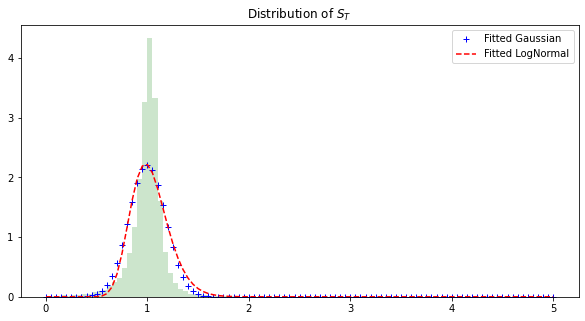

In [9]:
mu_ln, sigma_ln = mapping_gaussian_to_ln_parameters(rde.rde_paths.ys[:,-1,0].mean(),rde.rde_paths.ys[:,-1,0].std(ddof = 0))

f, ax = plt.subplots(figsize=(10, 5))   
nbbins = 100
nn, bins, patches = ax.hist(rde.rde_paths.ys[:,-1,0], bins=nbbins, density=True, facecolor='green', alpha=0.2)
ax.plot(bins, norm.pdf(bins,rde.rde_paths.ys[:,-1,0].mean(),rde.rde_paths.ys[:,-1,0].std(ddof = 0)), "b+", label="Fitted Gaussian")
ax.plot(bins, density_lognormal(bins, mu_ln, sigma_ln), "r--", label="Fitted LogNormal")
plt.legend(loc="best")
plt.title(r"Distribution of $S_T$")
plt.show()

In [10]:
## Recover the paths for the process $(\sigma_t)_{t\geq 0}$

sigma_paths = np.sqrt(params[0]*(rde.rde_paths.ys[:, :, 1]-params[1])**2 + params[2])

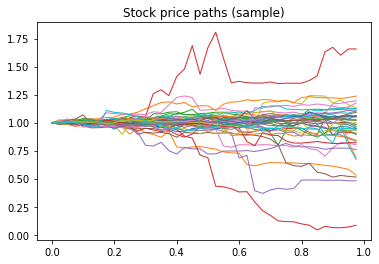

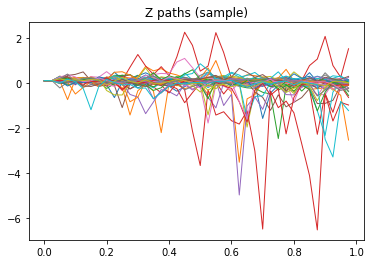

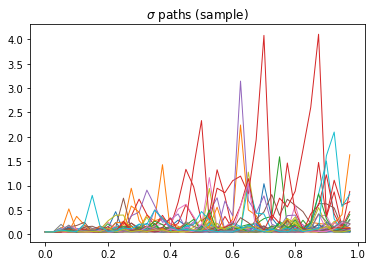

In [11]:
path_selection = np.random.choice(range(nbPaths), 40, False)

for k in path_selection:
    plt.plot(rde.rde_paths.ts[0, :], rde.rde_paths.ys[k, :, 0], linewidth=1)
plt.title("Stock price paths (sample)")
plt.show()

for k in path_selection:
    plt.plot(rde.rde_paths.ts[0, :], rde.rde_paths.ys[k, :, 1], linewidth=1)
plt.title("Z paths (sample)")
plt.show()

for k in path_selection:
    plt.plot(rde.rde_paths.ts[0, :], sigma_paths[k, :], linewidth=1)
plt.title(r'$\sigma$ paths (sample)')
plt.show()

## Run Monte Carlo computations for option prices

In [12]:
nbStrikes = 30
strikes = np.linspace(S0*np.exp(-0.25), S0*np.exp(0.25), nbStrikes)
log_moneyness = np.log(strikes/S0)

In [13]:
#############################
t0 = time.time()
rde.callPrice_RDE_QuadHeston_MC_givenPaths(strikes)
dtCalls = time.time() - t0
print("Computation time: ", dtCalls)
#############################

Computation time:  0.05531501770019531


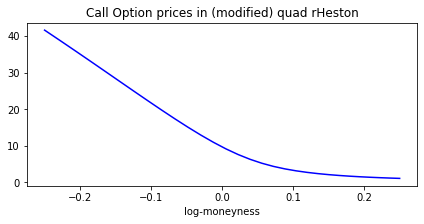

In [14]:
plt.figure(figsize=(7,3))
plt.plot(log_moneyness, rde.callPrices, 'b')
plt.xlabel('log-moneyness')
plt.title('Call Option prices in (modified) quad rHeston')
plt.show()

/Users/obonesin/Documents/GitHub/rough-vol-rough-paths/Jackels.py:539: RuntimeWarning: overflow encountered in cast
  while (iterations < N and abs(ds) > DBL_EPSILON * s):
/Users/obonesin/Documents/GitHub/rough-vol-rough-paths/Jackels.py:540: RuntimeWarning: overflow encountered in cast
  if (ds * ds_previous < 0):


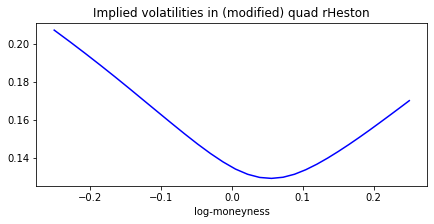

In [15]:
rde.implied_vol_givenCalls(strikes)
plt.figure(figsize=(7,3))
plt.plot(log_moneyness, rde.impliedVols, 'b')
plt.xlabel('log-moneyness')
plt.title('Implied volatilities in (modified) quad rHeston')
plt.show()

## Import option price data

In [16]:
r,q = 0.,0.
S0 = 179.83

data = pd.read_csv('dataOptionPrices.csv')
def logstrike(S0,K,T): return np.log(K/S0*np.exp(-(r-q)*T))
data['LogStrike'] = [logstrike(S0,K,T) for K,T in zip(data['Strike'],data['Expiration'])]

data['IV'] = [impliedVolJaeckelRational(S0, K, c, T) for K,T,c in zip(data['Strike'],data['Expiration'],data['midPrice'])]

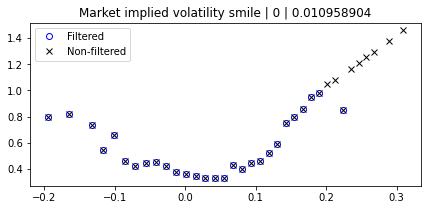

We use the filtered data for calibration only


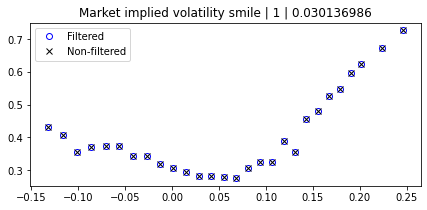

We use the filtered data for calibration only


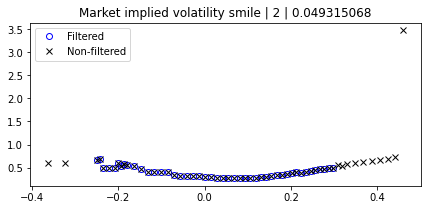

We use the filtered data for calibration only


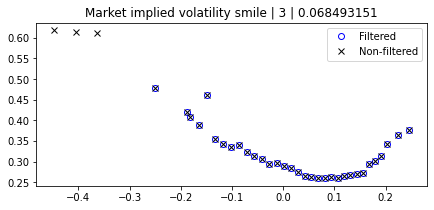

We use the filtered data for calibration only


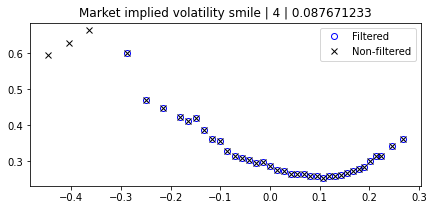

We use the filtered data for calibration only


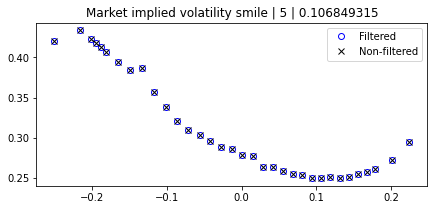

We use the filtered data for calibration only


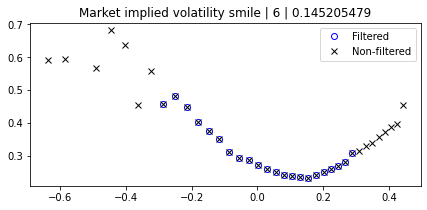

We use the filtered data for calibration only


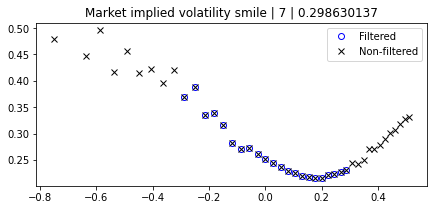

We use the filtered data for calibration only


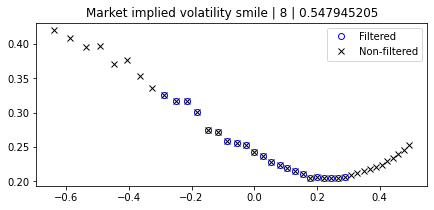

We use the filtered data for calibration only


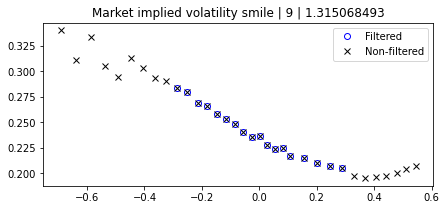

We use the filtered data for calibration only


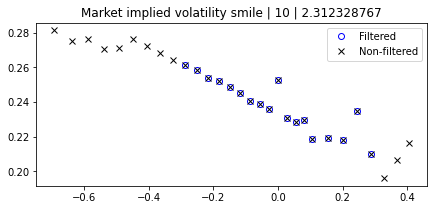

We use the filtered data for calibration only


In [17]:
logStrikeMin, logStrikeMax = -0.3, 0.3

ListMat = data["Expiration"].unique()
for (indexMat, T) in enumerate(ListMat):
    #indexMat = -2 ## Select maturity index
    
    df_filt = data[(data["Expiration"] == ListMat[indexMat]) & (data["IV"] >0.) & (data["IV"] <1.) & (data["LogStrike"] < logStrikeMax) & (data["LogStrike"] > logStrikeMin)]
    df_nonfilt = data[data["Expiration"] == ListMat[indexMat]]
    
    plt.figure(figsize=(7,3))
    plt.plot(df_filt["LogStrike"].values, df_filt["IV"].values, "bo", mfc="None", label="Filtered")
    plt.plot(df_nonfilt["LogStrike"].values, df_nonfilt["IV"].values, "kx", mfc="None", label="Non-filtered")
    plt.title("Market implied volatility smile | " + str((indexMat)) + " | " + str(T))
    plt.legend(loc="best")
    plt.show()
    print("We use the filtered data for calibration only")

## Choosing one slice

In [18]:
indexMat = -3
T = ListMat[indexMat]

In [19]:
df_filt = data[(data["Expiration"] == T) & (data["IV"] >0.) & (data["IV"] <1.) & (data["LogStrike"] < logStrikeMax) & (data["LogStrike"] > logStrikeMin)]

prices_market = df_filt["midPrice"]
ivs_market = df_filt["IV"].values
strikes = df_filt["Strike"].values
logstrikes = df_filt["LogStrike"].values

print("Maturity: ", T)


Maturity:  0.547945205


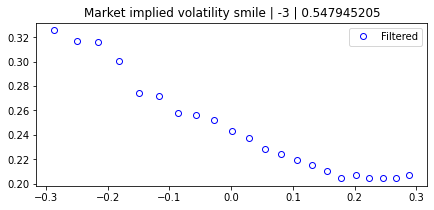

In [20]:
plt.figure(figsize=(7,3))
plt.plot(df_filt["LogStrike"].values, df_filt["IV"].values, "bo", mfc="None", label="Filtered")
plt.title("Market implied volatility smile | " + str((indexMat)) + " | " + str(T))
plt.legend(loc="best")
plt.show()

### Calibration on Call prices or on implied volatilities (fixed H)

#### Definition of the loss functions (one on the option prices, one on the implied volatilities) for the calibration

In [21]:
def lossFunction_ivs_fixedH_fixedrde(params, rde, strikes, ivs_market, dispPrint=False):
    """
    Loss function: we consider the L2 error on the implied volatilities
    Note that the rde has been fixed, namely its Brownian paths have been generated already
    """    

    rde.run_paths_RDE_QuadHeston(params)
    rde.callPrice_RDE_QuadHeston_MC_givenPaths(strikes)
    rde.implied_vol_givenCalls(strikes)
    #print("IVs: ", rde.impliedVols)
    
    normError = np.sum([(a-b)**2 for (a,b) in zip(rde.impliedVols, ivs_market)])
    
    if dispPrint:
        print("Parameters: ", [np.round(p, 5) for p in params], " || L2 error: ", np.round(normError, 5))
    return normError


def lossFunction_prices_fixedH_fixedrde(params, rde, strikes, prices_market, dispPrint=False):
    """
    Loss function: we consider the L2 error on the option prices
    Note that the rde has been fixed, namely its Brownian paths have been generated already
    """    

    rde.run_paths_RDE_QuadHeston(params)
    rde.callPrice_RDE_QuadHeston_MC_givenPaths(strikes)
    
    normError = np.sum([((a-b)/rde.S0)**2 for (a,b) in zip(rde.callPrices, prices_market)])
    
    if dispPrint:
        print("Parameters: ", [np.round(p, 5) for p in params], " || L2 error: ", np.round(normError, 5))
    return normError


### Initial randomisation, with H fixed

In [22]:
H, kappa = 0.1, 1
nbPaths = 100000
nb_grid_points = 50

## Calibration bound domain. Note that lambda is frozen to 1
calibBounds_noH = ((0.1,1.), (0.01,1.), (0.01,0.5), (0.05,0.5), (1., 1.), (0.3,1.5), (0.08,0.3))

In [ ]:
rde = RDE_QuadHeston(nb_grid_points, nbPaths, T, H, S0)
rde.run__init__(timerYesNo=True)

nb_init_test = 250
loss_best_init = 100
a, b, c, theta, lam, eta, y0 = 0.1, 0.4, 0.05, 0.1, 1., 0.5, .23
p_best_init = a, b, c, theta, lam, eta, y0


for i in range(nb_init_test):
    progressBar(i, nb_init_test, message = "Running test parameters")
    a = np.random.rand()*(calibBounds_noH[0][1] - calibBounds_noH[0][0])  + calibBounds_noH[0][0]
    b = np.random.rand()*(calibBounds_noH[1][1] - calibBounds_noH[1][0])  + calibBounds_noH[1][0]
    c = np.random.rand()*(calibBounds_noH[2][1] - calibBounds_noH[2][0])  + calibBounds_noH[2][0]
    theta = np.random.rand()*(calibBounds_noH[3][1] - calibBounds_noH[3][0])  + calibBounds_noH[3][0]
    lam = np.random.rand()*(calibBounds_noH[4][1] - calibBounds_noH[4][0])  + calibBounds_noH[4][0]
    eta = np.random.rand()*(calibBounds_noH[5][1] - calibBounds_noH[5][0])  + calibBounds_noH[5][0]
    y0 = np.random.rand()*(calibBounds_noH[6][1] - calibBounds_noH[6][0])  + calibBounds_noH[6][0]
    
    params = a, b, c, theta, lam, eta, y0


    #currentLoss = lossFunction_ivs_fixedH_fixedrde(params, rde, strikes, ivs_market, dispPrint=False)
    currentLoss = lossFunction_prices_fixedH_fixedrde(params, rde, strikes, prices_market, dispPrint=False)
    
    #print(params, currentLoss)
    if loss_best_init > currentLoss:
        p_best_init = params
        loss_best_init = currentLoss

print("****************************")
print("Optimal parameters: ", [np.round(p, 5) for p in p_best_init], " | H= ", np.round(H, 2), " || Minimal L2 error: ", np.round(loss_best_init, 5))
    

In [ ]:
##Optimal parameters:  [0.11496, 0.05584, 0.00883, 0.11264, 0.22936, 0.4673, 0.53798]  | H=  0.1  || Minimal L2 error:  1.16115

In [12]:
#H = 0.11
#nbPaths = 10000
rde = RDE_QuadHeston(nb_grid_points, nbPaths, T, H, S0)
rde.run__init__(timerYesNo=True)

Initialisation time (Simulating the Brownian paths):  127.39047932624817


In [19]:
p_best_init = [0.32937, 0.30828, 0.03876, 0.24681, 1.0, 0.90858, 0.16205]
p_best_init = [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]

In [20]:
optim = minimize(lossFunction_prices_fixedH_fixedrde, p_best_init, args=(rde, strikes, prices_market, True), method='L-BFGS-B', bounds=calibBounds_noH, tol=1E-6, options={'ftol':1E-14})
optimal_param_noH = optim.x
print("Calibration completed")

Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]  || L2 error:  0.00069
Parameters:  [0.3152, 0.3044, 0.01, 0.2468, 1.0, 0.9086, 0.10998]  || L2 error:  0.00407
Parameters:  [0.3152, 0.3044, 0.01, 0.2468, 1.0, 0.9086, 0.10998]  || L2 error:  0.00407
Parameters:  [0.3152, 0.3044, 0.01, 0.2468, 1.0, 0.9086, 0.10998]  || L2 error:  0.00407
Parameters:  [0.3152, 0.3044, 0.01, 0.2468, 1.0, 0.9086, 0.10998]  || L2 error:  0.00407
Parameters:  [

In [21]:
print("Initial parameters: ", [np.round(p, 4) for p in p_best_init])
print("Optimal parameters: ", [np.round(p, 4) for p in optimal_param_noH])

Initial parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]
Optimal parameters:  [0.3152, 0.3044, 0.0299, 0.2468, 1.0, 0.9086, 0.1158]


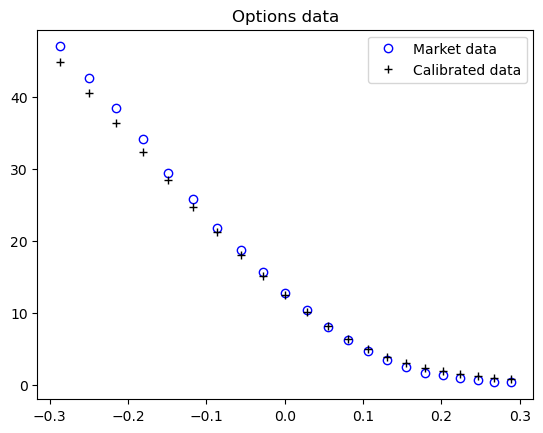

In [23]:
rde.callPrice_RDE_QuadHeston_MC(optimal_param_noH, strikes)
plt.plot(logstrikes, prices_market, 'bo', mfc="None", label="Market data")
plt.plot(logstrikes, rde.callPrices, 'k+', label="Calibrated data")
plt.legend(loc="best")
plt.title("Options data")
plt.show()